# 📊 Visualización para EDA
## Reglas claras: qué gráfico usar según el tipo de dato
**Diplomatura en IA — UBA · Trabajo Final · Clase 2**

---

### La pregunta clave antes de graficar

> **¿Qué tipo de variable quiero mostrar y qué quiero comunicar?**

| Situación | Gráfico recomendado |
|---|---|
| 1 variable numérica | Histograma + KDE |
| 1 variable categórica | Barras horizontales (countplot) |
| Numérica vs. Numérica | Scatter plot · Regresión |
| Numérica vs. Categórica | Box plot · Violin · Strip |
| Categórica vs. Categórica | Heatmap de conteos |
| Evolución en el tiempo | Line plot |
| Comparar distribuciones | KDE superpuestas · ECDF |
| Correlación entre muchas vars | Heatmap de correlación |
| Texto / NLP | Barras de frecuencia · Wordcloud |

**Estructura del notebook:**
1. Setup y datos
2. Regla 1 — Una variable numérica
3. Regla 2 — Una variable categórica
4. Regla 3 — Numérica vs. Numérica
5. Regla 4 — Numérica vs. Categórica
6. Regla 5 — Categórica vs. Categórica
7. Regla 6 — Comparar distribuciones
8. Regla 7 — Correlación entre muchas variables
9. Regla 8 — Datos de texto / NLP
10. Panel EDA completo
11. ✏️ Tu turno

## 0. Setup e instalación

In [1]:
!pip install -q seaborn matplotlib pandas numpy scikit-learn wordcloud

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# ── Estilo global ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="husl", font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
})

PALETTE = sns.color_palette("Set2")
COLOR_A = PALETTE[0]
COLOR_B = PALETTE[1]
COLOR_C = PALETTE[2]
COLOR_D = PALETTE[3]

np.random.seed(42)
print('✅ Setup OK')

✅ Setup OK


## 1. Datasets

Generamos cuatro datasets sintéticos con las mismas propiedades estadísticas que los datasets clásicos de seaborn (`tips`, `titanic`, `penguins`) más `iris` de sklearn. Son idénticos en estructura pero no requieren acceso a internet.

In [3]:
# ── Dataset 1: TIPS (propinas en restaurante) ────────────────────────────────
n = 244
days    = np.random.choice(['Thur','Fri','Sat','Sun'], n, p=[0.25, 0.08, 0.36, 0.31])
time    = np.where(np.isin(days, ['Thur','Fri']), 'Lunch', 'Dinner')
sex     = np.random.choice(['Male','Female'], n, p=[0.64, 0.36])
smoker  = np.random.choice(['No','Yes'], n, p=[0.62, 0.38])
size    = np.random.choice([1,2,3,4,5,6], n, p=[0.02, 0.46, 0.18, 0.24, 0.05, 0.05])
total_bill = np.clip(np.random.lognormal(2.7, 0.47, n), 3, 50)
tip     = np.clip(total_bill * np.clip(np.random.normal(0.16, 0.06, n), 0.05, 0.5) +
                  np.random.normal(0, 0.3, n), 1, 10)

tips = pd.DataFrame({
    'total_bill': total_bill.round(2), 'tip': tip.round(2),
    'sex': sex, 'smoker': smoker, 'day': days, 'time': time, 'size': size
})

# ── Dataset 2: TITANIC ────────────────────────────────────────────────────────
n_t   = 891
pclass = np.random.choice([1,2,3], n_t, p=[0.24, 0.21, 0.55])
sex_t  = np.random.choice(['male','female'], n_t, p=[0.65, 0.35])
age_t  = np.clip(np.random.normal(29.7, 14.5, n_t), 0.4, 80)
fare   = np.clip(np.exp(np.random.normal(3.2, 1.0, n_t)), 0, 512)
surv_p = np.clip(
    (0.19*(pclass==1) + 0.47*(pclass==2) + 0.24*(pclass==3)) *
    (2.5*(sex_t=='female') + 0.5*(sex_t=='male')), 0, 1)
survived = (np.random.rand(n_t) < surv_p).astype(int)

titanic = pd.DataFrame({
    'survived': survived, 'pclass': pclass, 'sex': sex_t,
    'age': age_t.round(1), 'fare': fare.round(2)
})
titanic['pclass_label'] = titanic['pclass'].map({1:'1a Clase', 2:'2a Clase', 3:'3a Clase'})

# ── Dataset 3: PENGUINOS de Palmer ────────────────────────────────────────────
n_p     = 333
species = np.random.choice(['Adelie','Chinstrap','Gentoo'], n_p, p=[0.44, 0.20, 0.36])
bill_len = np.where(species=='Adelie',    np.random.normal(38.8, 2.7, n_p),
           np.where(species=='Chinstrap', np.random.normal(48.8, 3.3, n_p),
                                          np.random.normal(47.5, 3.1, n_p)))
bill_dep = np.where(species=='Adelie',    np.random.normal(18.3, 1.2, n_p),
           np.where(species=='Chinstrap', np.random.normal(18.4, 1.1, n_p),
                                          np.random.normal(15.0, 1.0, n_p)))
flipper  = np.where(species=='Adelie',    np.random.normal(190, 6.5, n_p),
           np.where(species=='Chinstrap', np.random.normal(196, 7.1, n_p),
                                          np.random.normal(217, 6.5, n_p)))
mass     = np.where(species=='Adelie',    np.random.normal(3700, 460, n_p),
           np.where(species=='Chinstrap', np.random.normal(3730, 385, n_p),
                                          np.random.normal(5080, 500, n_p)))

penguins = pd.DataFrame({
    'species': species,
    'bill_length_mm':    bill_len.round(1),
    'bill_depth_mm':     bill_dep.round(1),
    'flipper_length_mm': flipper.round(0).astype(int),
    'body_mass_g':       mass.round(0).astype(int)
})
palette_p = {'Adelie': COLOR_A, 'Chinstrap': COLOR_B, 'Gentoo': COLOR_C}

# ── Dataset 4: IRIS (sklearn) ─────────────────────────────────────────────────
from sklearn.datasets import load_iris
iris_raw = load_iris(as_frame=True)
iris = iris_raw.frame.rename(columns={'target': 'species_id'})
iris['species'] = iris['species_id'].map({0:'setosa', 1:'versicolor', 2:'virginica'})
num_cols_iris = ['sepal length (cm)', 'sepal width (cm)',
                 'petal length (cm)', 'petal width (cm)']

# ── Dataset 5: NLP — Boletín Oficial Salta ────────────────────────────────────
distribucion_nlp = {
    'decreto': (9, 1200, 400),
    'resolucion': (9, 650, 250),
    'adjudicacion': (22, 90, 40),
    'sucesorio': (11, 140, 60),
    'edicto': (9, 180, 80),
    'contratacion': (17, 100, 45),
}

nlp_rows = []
for tipo, (n_docs, media, std) in distribucion_nlp.items():
    for _ in range(n_docs):
        pal = int(np.clip(np.random.normal(media, std), 30, 5000))
        nlp_rows.append({'tipo': tipo, 'palabras': pal, 'tokens': int(pal * 1.3)})

df_nlp = pd.DataFrame(nlp_rows)
colores_nlp = {
    'decreto':     '#0D9488', 'resolucion':   '#7C3AED',
    'adjudicacion':'#DC2626', 'sucesorio':    '#64748B',
    'edicto':      '#F59E0B', 'contratacion': '#F97316',
}

print("Datasets listos:")
print(f"  tips:     {tips.shape}")
print(f"  titanic:  {titanic.shape}  — supervivencia: {titanic.survived.mean():.0%}")
print(f"  penguins: {penguins.shape}")
print(f"  iris:     {iris.shape}")
print(f"  nlp:      {df_nlp.shape}  — tipos: {df_nlp.tipo.unique().tolist()}")

Datasets listos:
  tips:     (244, 7)
  titanic:  (891, 6)  — supervivencia: 33%
  penguins: (333, 5)
  iris:     (150, 6)
  nlp:      (77, 3)  — tipos: ['decreto', 'resolucion', 'adjudicacion', 'sucesorio', 'edicto', 'contratacion']


---
## Regla 1 · Una variable numérica → Histograma + KDE

**Cuándo:** Querés ver cómo se distribuye una variable numérica.

**Regla de oro:** Usá siempre las dos capas:
- **Histograma** → cuenta observaciones reales (exacto)
- **KDE** (Kernel Density Estimate) → curva suavizada de la distribución

> ⚠️ Un histograma solo puede engañar si `bins` está mal elegido. El KDE da contexto.

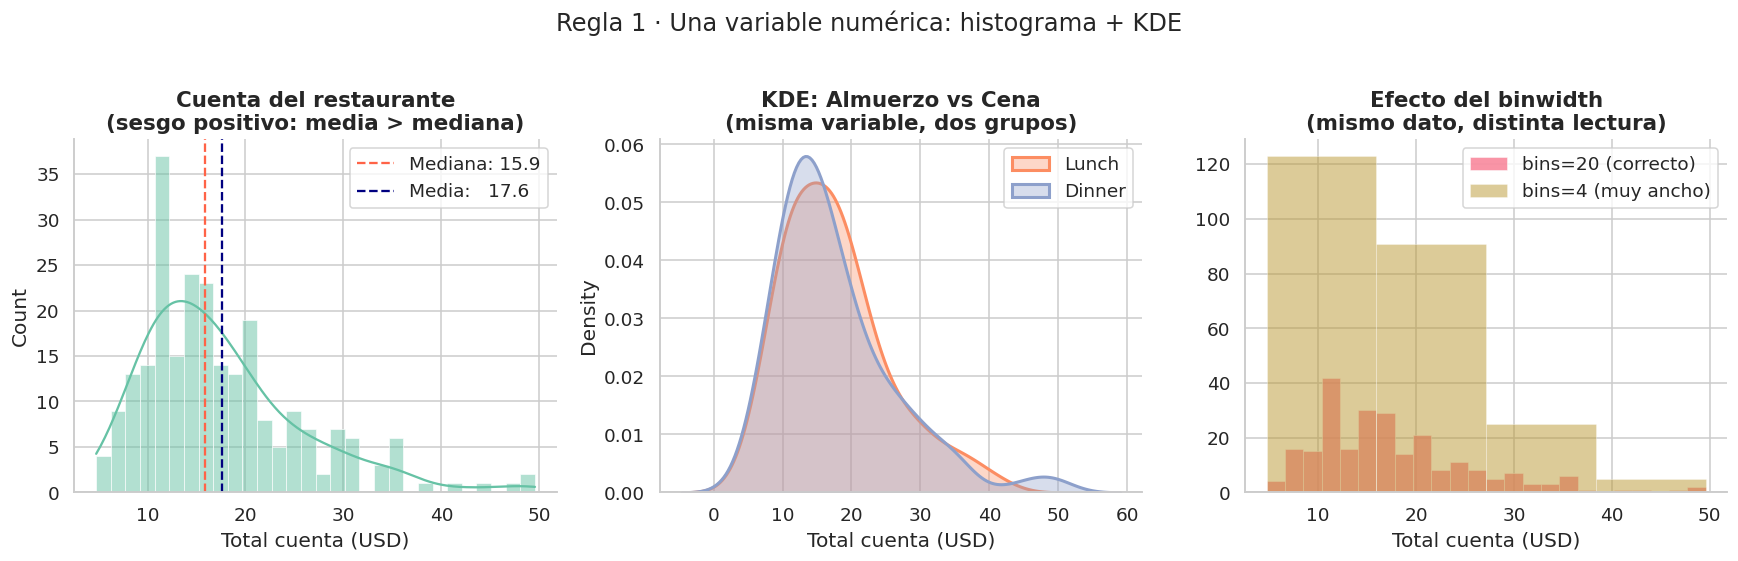

Estadísticos de total_bill:
count    244.00
mean      17.56
std        8.21
min        4.76
25%       11.59
50%       15.89
75%       20.76
max       49.56
Name: total_bill, dtype: float64

Skewness: 1.28  → distribución con cola derecha


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── 1a: histplot + KDE + líneas de tendencia central ──────────────────────────
sns.histplot(tips['total_bill'], bins=30, kde=True, color=COLOR_A,
             ax=axes[0], edgecolor='white', linewidth=0.4)
axes[0].axvline(tips['total_bill'].median(), color='tomato', linestyle='--',
                label=f'Mediana: {tips["total_bill"].median():.1f}')
axes[0].axvline(tips['total_bill'].mean(),   color='navy',   linestyle='--',
                label=f'Media:   {tips["total_bill"].mean():.1f}')
axes[0].set_title('Cuenta del restaurante\n(sesgo positivo: media > mediana)')
axes[0].set_xlabel('Total cuenta (USD)')
axes[0].legend()

# ── 1b: KDE superpuestas para comparar grupos ──────────────────────────────────
for time_val, color in zip(['Lunch','Dinner'], [COLOR_B, COLOR_C]):
    subset = tips[tips['time'] == time_val]['total_bill']
    sns.kdeplot(subset, ax=axes[1], label=time_val,
                color=color, fill=True, alpha=0.35, linewidth=2)
axes[1].set_title('KDE: Almuerzo vs Cena\n(misma variable, dos grupos)')
axes[1].set_xlabel('Total cuenta (USD)')
axes[1].legend()

# ── 1c: efecto del número de bins ─────────────────────────────────────────────
for bw, alpha, label in [(2, 0.75, 'bins=20 (correcto)'),
                          (10, 0.5, 'bins=4 (muy ancho)')]:
    n_bins = max(1, int(tips['total_bill'].max() / bw))
    axes[2].hist(tips['total_bill'], bins=n_bins, alpha=alpha,
                 label=label, edgecolor='white', linewidth=0.4)
axes[2].set_title('Efecto del binwidth\n(mismo dato, distinta lectura)')
axes[2].set_xlabel('Total cuenta (USD)')
axes[2].legend()

plt.suptitle('Regla 1 · Una variable numérica: histograma + KDE', y=1.02)
plt.tight_layout()
plt.show()

print("Estadísticos de total_bill:")
print(tips['total_bill'].describe().round(2))
print(f"\nSkewness: {tips['total_bill'].skew():.2f}  → distribución con cola derecha")

📝 **Hallazgo:** La cuenta tiene distribución sesgada positiva (skewness > 0). Mediana < Media porque los valores altos tiran la media hacia arriba.

**Impacto en el modelo:** Si usamos longitud de texto como feature, una distribución así puede beneficiarse de una transformación logarítmica.

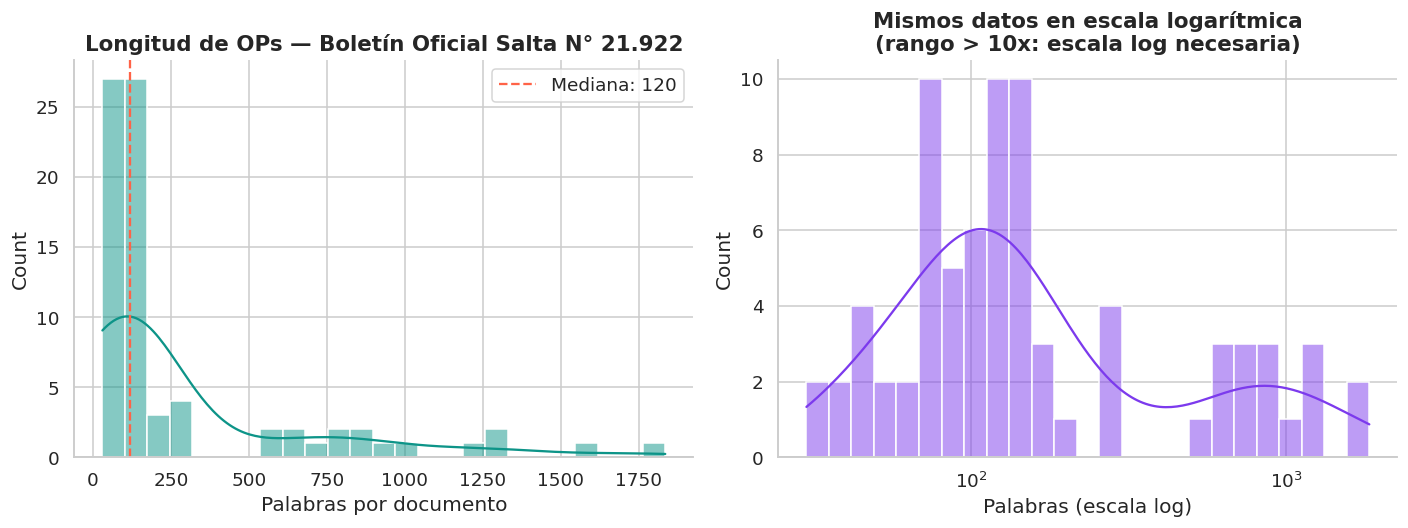

Media:   294 palabras
Mediana: 120 palabras
Min:     30
Max:     1835


In [5]:
# ── Aplicación NLP: distribución de longitud de documentos ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df_nlp['palabras'], bins=25, kde=True, color='#0D9488',
             ax=axes[0], edgecolor='white')
axes[0].axvline(df_nlp['palabras'].median(), color='tomato', linestyle='--',
                label=f'Mediana: {df_nlp["palabras"].median():.0f}')
axes[0].set_title('Longitud de OPs — Boletín Oficial Salta N° 21.922')
axes[0].set_xlabel('Palabras por documento')
axes[0].legend()

# Escala log: necesaria cuando el rango es > 10x
sns.histplot(df_nlp['palabras'], bins=25, kde=True, color='#7C3AED',
             ax=axes[1], edgecolor='white', log_scale=True)
axes[1].set_title('Mismos datos en escala logarítmica\n(rango > 10x: escala log necesaria)')
axes[1].set_xlabel('Palabras (escala log)')

plt.tight_layout()
plt.show()

print(f"Media:   {df_nlp['palabras'].mean():.0f} palabras")
print(f"Mediana: {df_nlp['palabras'].median():.0f} palabras")
print(f"Min:     {df_nlp['palabras'].min()}")
print(f"Max:     {df_nlp['palabras'].max()}")

---
## Regla 2 · Una variable categórica → Barras

**Cuándo:** Querés contar cuántos hay de cada categoría.

**Reglas:**
- **Ordenar** de mayor a menor (facilita la lectura)
- **Horizontal** si las etiquetas son largas
- **Agregar valores** encima o al lado de cada barra
- **Evitar** el gráfico de torta salvo 2-3 categorías

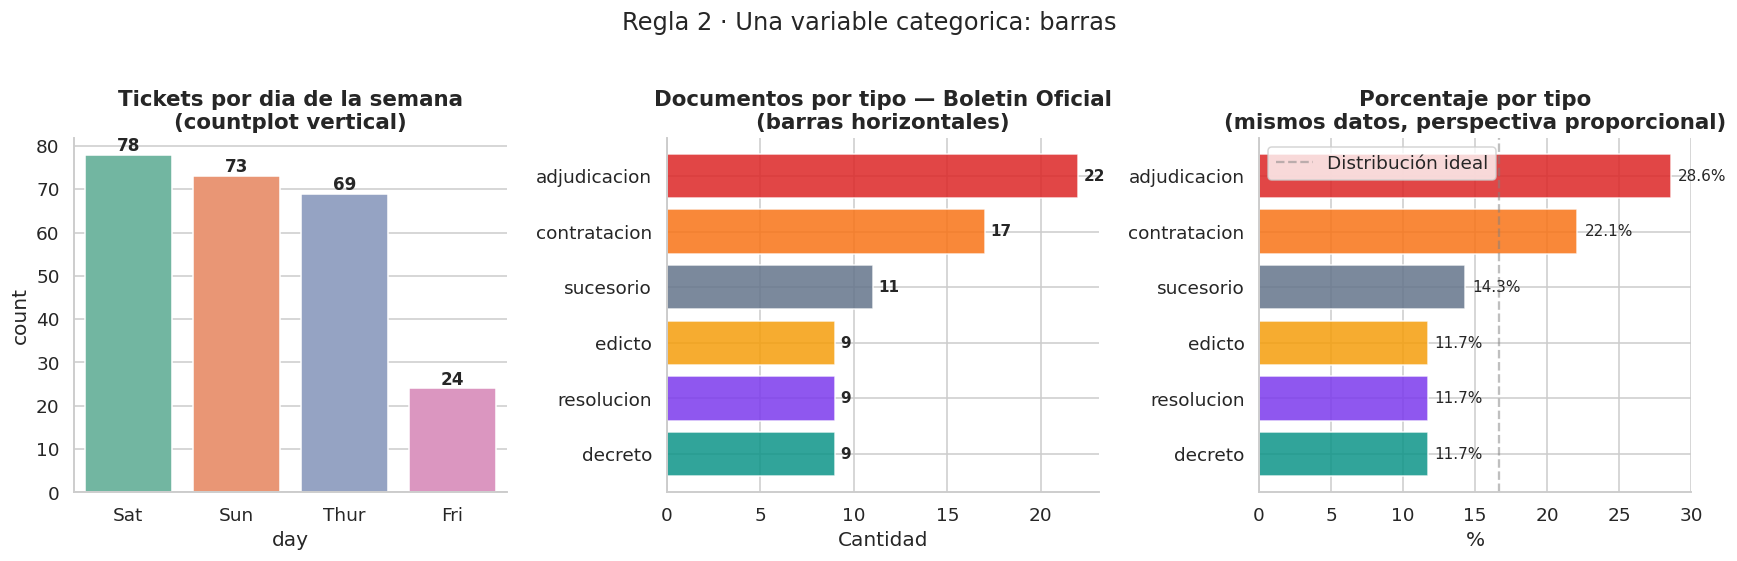

Ratio de desbalance: 2.4444444444444446
-> Ratio > 5x: usar F1-macro como metrica principal (Track B)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── 2a: countplot vertical (pocas categorías, etiquetas cortas) ───────────────
order = tips['day'].value_counts().index
ax = sns.countplot(data=tips, x='day', order=order, palette='Set2', ax=axes[0])
axes[0].set_title('Tickets por dia de la semana\n(countplot vertical)')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# ── 2b: barras horizontales ordenadas (etiquetas largas) ──────────────────────
conteo = df_nlp['tipo'].value_counts().sort_values()
c_list = [colores_nlp.get(t, 'gray') for t in conteo.index]
bars = axes[1].barh(conteo.index, conteo.values, color=c_list, alpha=0.85, edgecolor='white')
axes[1].set_title('Documentos por tipo — Boletin Oficial\n(barras horizontales)')
axes[1].set_xlabel('Cantidad')
for bar, val in zip(bars, conteo.values):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=10, fontweight='bold')

# ── 2c: porcentajes ───────────────────────────────────────────────────────────
pct = (df_nlp['tipo'].value_counts(normalize=True) * 100).sort_values()
c_list2 = [colores_nlp.get(t, 'gray') for t in pct.index]
axes[2].barh(pct.index, pct.values, color=c_list2, alpha=0.85, edgecolor='white')
axes[2].set_title('Porcentaje por tipo\n(mismos datos, perspectiva proporcional)')
axes[2].set_xlabel('%')
ideal = 100 / len(pct)
axes[2].axvline(ideal, color='gray', linestyle='--', alpha=0.5, label='Distribución ideal')
axes[2].legend()
for i, (idx, val) in enumerate(pct.items()):
    axes[2].text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=10)

plt.suptitle('Regla 2 · Una variable categorica: barras', y=1.02)
plt.tight_layout()
plt.show()

print("Ratio de desbalance:", df_nlp['tipo'].value_counts().max() / df_nlp['tipo'].value_counts().min())
print("-> Ratio > 5x: usar F1-macro como metrica principal (Track B)")

---
## Regla 3 · Numérica vs. Numérica → Scatter plot

**Cuándo:** Querés ver la relación (correlación) entre dos variables continuas.

| Variante | Cuándo |
|---|---|
| `scatter` básico | N < 1.000 |
| `scatter + regplot` | Para cuantificar la tendencia |
| `hexbin / kdeplot 2D` | N > 5.000 (overplotting) |

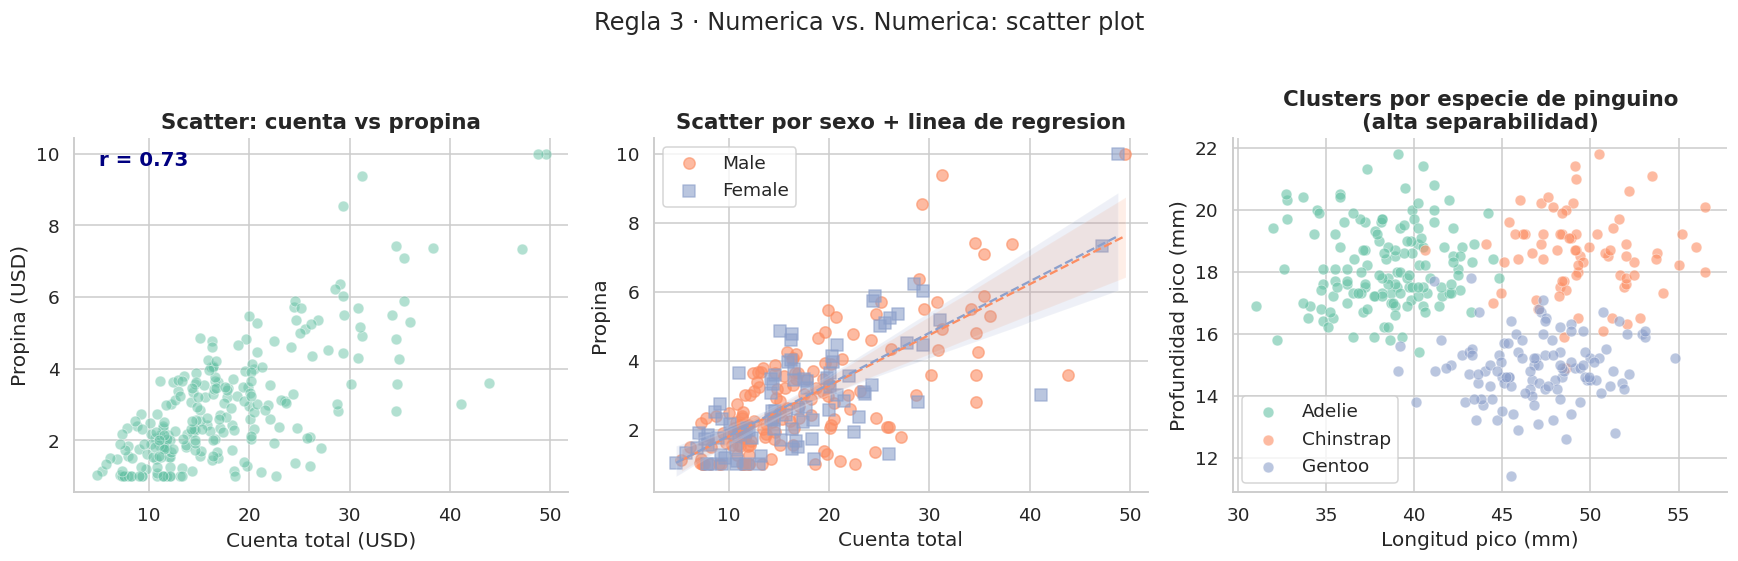

El scatter de pinguinos muestra 3 clusters bien separados.
-> Un clasificador simple puede funcionar bien (Track B).


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── 3a: scatter básico + correlación ──────────────────────────────────────────
axes[0].scatter(tips['total_bill'], tips['tip'],
                alpha=0.5, edgecolors='white', linewidth=0.5, color=COLOR_A, s=50)
axes[0].set_xlabel('Cuenta total (USD)')
axes[0].set_ylabel('Propina (USD)')
axes[0].set_title('Scatter: cuenta vs propina')
r = tips[['total_bill','tip']].corr().iloc[0,1]
axes[0].text(0.05, 0.92, f'r = {r:.2f}', transform=axes[0].transAxes,
             fontsize=13, color='navy', fontweight='bold')

# ── 3b: scatter con categoría + línea de regresión ────────────────────────────
for s_val, color, marker in zip(['Male','Female'], [COLOR_B, COLOR_C], ['o','s']):
    mask = tips['sex'] == s_val
    axes[1].scatter(tips.loc[mask,'total_bill'], tips.loc[mask,'tip'],
                    alpha=0.6, label=s_val, color=color, marker=marker, s=55)
sns.regplot(data=tips[tips.sex=='Male'],   x='total_bill', y='tip',
            scatter=False, ax=axes[1], color=COLOR_B,
            line_kws={'linewidth':1.5, 'linestyle':'--'})
sns.regplot(data=tips[tips.sex=='Female'], x='total_bill', y='tip',
            scatter=False, ax=axes[1], color=COLOR_C,
            line_kws={'linewidth':1.5, 'linestyle':'--'})
axes[1].set_title('Scatter por sexo + linea de regresion')
axes[1].set_xlabel('Cuenta total')
axes[1].set_ylabel('Propina')
axes[1].legend()

# ── 3c: pingüinos — clusters naturales visibles ───────────────────────────────
for sp, color in palette_p.items():
    mask = penguins['species'] == sp
    axes[2].scatter(penguins.loc[mask,'bill_length_mm'],
                    penguins.loc[mask,'bill_depth_mm'],
                    alpha=0.6, label=sp, color=color, s=50,
                    edgecolors='white', linewidth=0.4)
axes[2].set_title('Clusters por especie de pinguino\n(alta separabilidad)')
axes[2].set_xlabel('Longitud pico (mm)')
axes[2].set_ylabel('Profundidad pico (mm)')
axes[2].legend()

plt.suptitle('Regla 3 · Numerica vs. Numerica: scatter plot', y=1.02)
plt.tight_layout()
plt.show()

print("El scatter de pinguinos muestra 3 clusters bien separados.")
print("-> Un clasificador simple puede funcionar bien (Track B).")

---
## Regla 4 · Numérica vs. Categórica → Box plot (la más útil en EDA)

| Gráfico | Qué muestra | Cuándo |
|---|---|---|
| `boxplot` | Q1, mediana, Q3, outliers | Siempre como primera exploración |
| `violinplot` | Distribución completa (KDE) | Cuando la forma importa |
| `stripplot` | Puntos individuales | Cuando N < 100 |

> 💡 **Combinación ideal:** `boxplot` (estructura) + `stripplot` (puntos individuales)

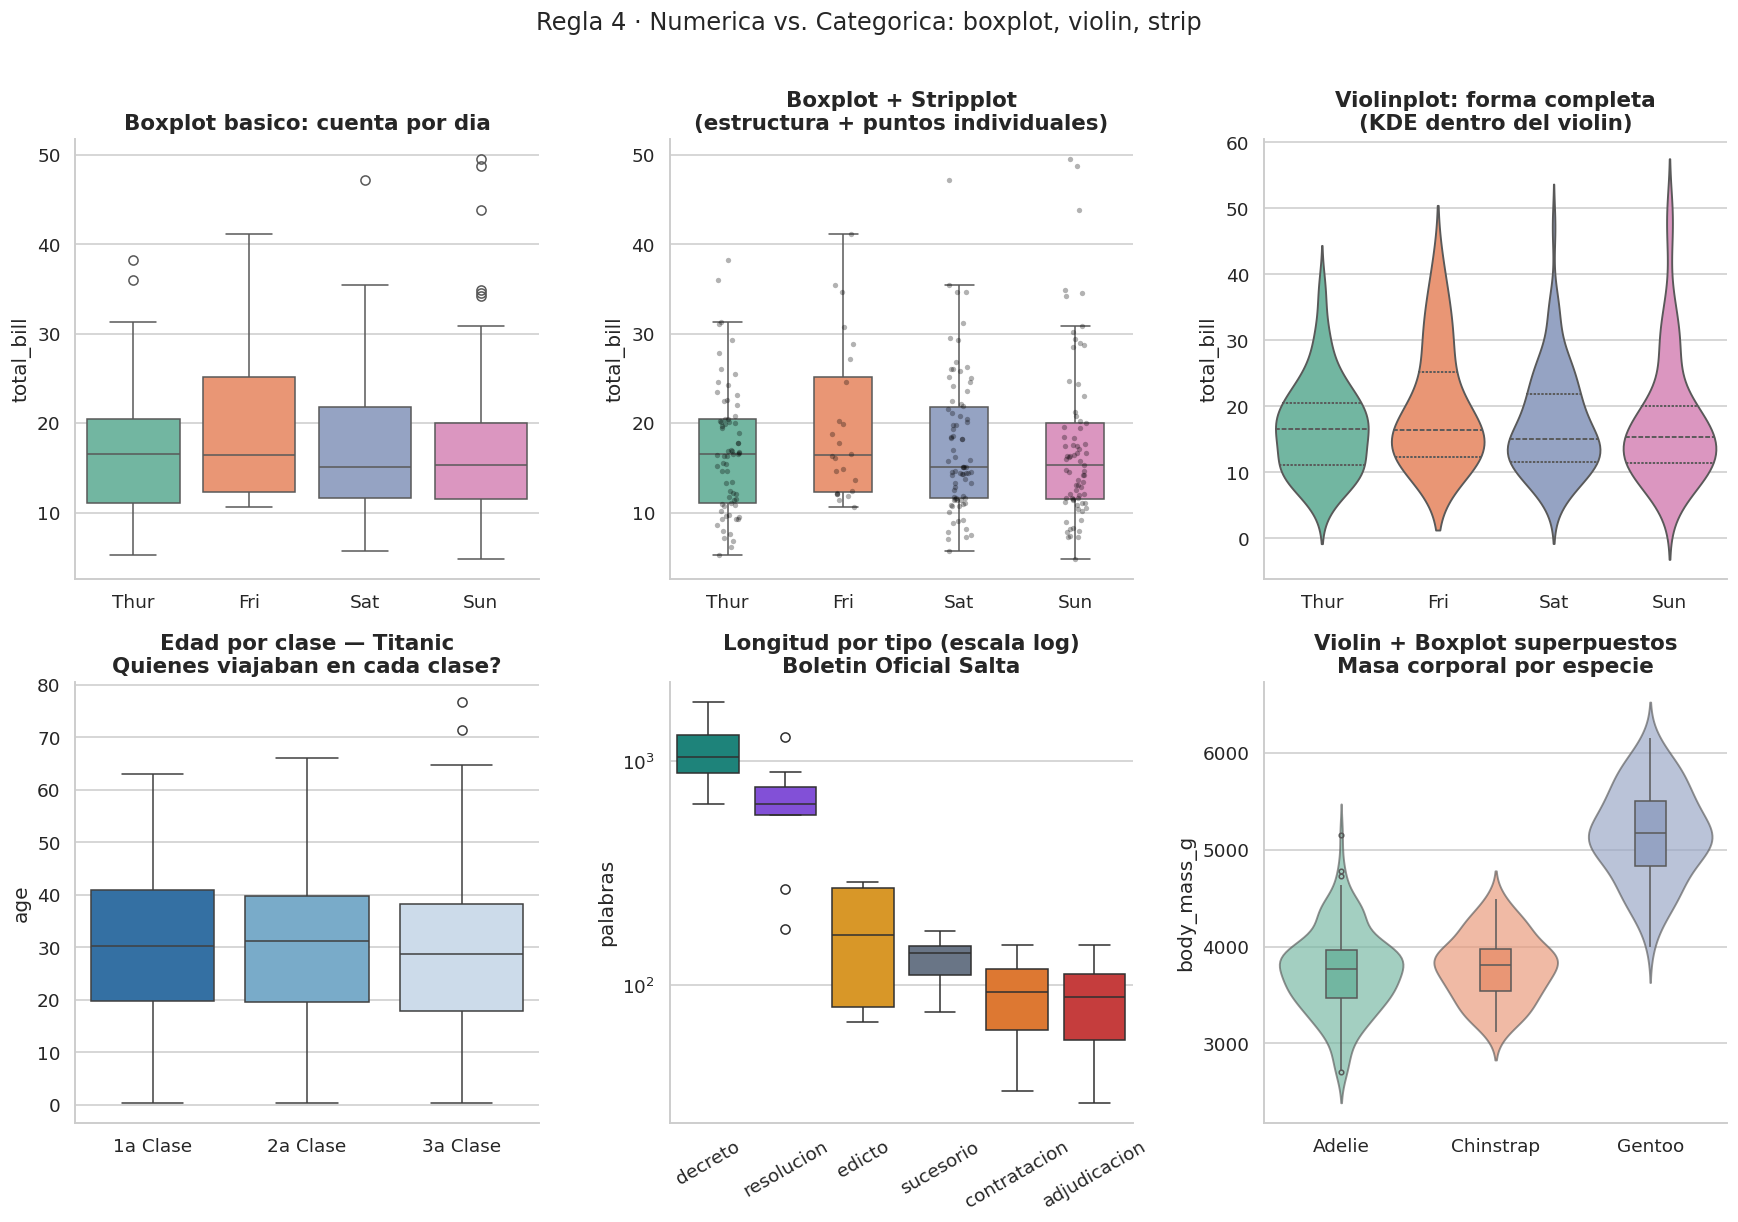

Longitud por tipo de documento:
              median  min   max
tipo                           
decreto       1040.0  646  1835
resolucion     645.0  179  1282
edicto         168.0   69   288
sucesorio      140.0   76   175
contratacion    94.0   34   151
adjudicacion    88.5   30   152


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 11))

# ── 4a: boxplot básico ────────────────────────────────────────────────────────
sns.boxplot(data=tips, x='day', y='total_bill',
            order=['Thur','Fri','Sat','Sun'], palette='Set2', ax=axes[0,0])
axes[0,0].set_title('Boxplot basico: cuenta por dia')
axes[0,0].set_xlabel('')

# ── 4b: boxplot + stripplot (la combinacion ideal) ────────────────────────────
sns.boxplot(data=tips, x='day', y='total_bill',
            order=['Thur','Fri','Sat','Sun'], palette='Set2',
            ax=axes[0,1], showfliers=False, width=0.5)
sns.stripplot(data=tips, x='day', y='total_bill',
              order=['Thur','Fri','Sat','Sun'], color='black',
              alpha=0.3, size=3.5, jitter=True, ax=axes[0,1])
axes[0,1].set_title('Boxplot + Stripplot\n(estructura + puntos individuales)')
axes[0,1].set_xlabel('')

# ── 4c: violinplot ────────────────────────────────────────────────────────────
sns.violinplot(data=tips, x='day', y='total_bill',
               order=['Thur','Fri','Sat','Sun'], palette='Set2',
               ax=axes[0,2], inner='quartile')
axes[0,2].set_title('Violinplot: forma completa\n(KDE dentro del violin)')
axes[0,2].set_xlabel('')

# ── 4d: titanic — edad por clase ─────────────────────────────────────────────
sns.boxplot(data=titanic, x='pclass_label', y='age',
            order=['1a Clase','2a Clase','3a Clase'],
            palette='Blues_r', ax=axes[1,0])
axes[1,0].set_title('Edad por clase — Titanic\nQuienes viajaban en cada clase?')
axes[1,0].set_xlabel('')

# ── 4e: longitud por tipo NLP (escala log) ───────────────────────────────────
orden = df_nlp.groupby('tipo')['palabras'].median().sort_values(ascending=False).index
c_list = [colores_nlp.get(t, 'gray') for t in orden]
sns.boxplot(data=df_nlp, x='tipo', y='palabras', order=orden,
            palette=colores_nlp, ax=axes[1,1])
axes[1,1].set_yscale('log')
axes[1,1].set_title('Longitud por tipo (escala log)\nBoletin Oficial Salta')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=30)

# ── 4f: violin + boxplot superpuestos ────────────────────────────────────────
sns.violinplot(data=penguins, x='species', y='body_mass_g',
               palette=palette_p, ax=axes[1,2], inner=None, alpha=0.65)
sns.boxplot(data=penguins, x='species', y='body_mass_g',
            palette=palette_p, ax=axes[1,2], width=0.2,
            showcaps=False, flierprops={'marker':'o','markersize':3})
axes[1,2].set_title('Violin + Boxplot superpuestos\nMasa corporal por especie')
axes[1,2].set_xlabel('')

plt.suptitle('Regla 4 · Numerica vs. Categorica: boxplot, violin, strip', y=1.01)
plt.tight_layout()
plt.show()

# Estadísticas de longitud por tipo (NLP)
print("Longitud por tipo de documento:")
print(df_nlp.groupby('tipo')['palabras'].agg(['median','min','max'])
      .sort_values('median', ascending=False).to_string())

📝 **Hallazgo NLP:** Los decretos tienen mediana ~1.200 palabras vs. adjudicaciones ~90 palabras (ratio 13x). La longitud es un feature muy discriminante para clasificación.

**Para Track B:** Un clasificador con solo la longitud como feature ya tiene poder predictivo.

---
## Regla 5 · Categórica vs. Categórica → Heatmap de conteos

**Cuándo:** Querés ver cómo se distribuyen dos variables categóricas entre sí.

**Reglas:**
- Usar `pd.crosstab()` para la tabla de contingencia
- Mostrar versión de conteos Y versión de proporciones
- `cmap='RdBu_r'` para proporciones con centro en 50%
- Siempre `annot=True`

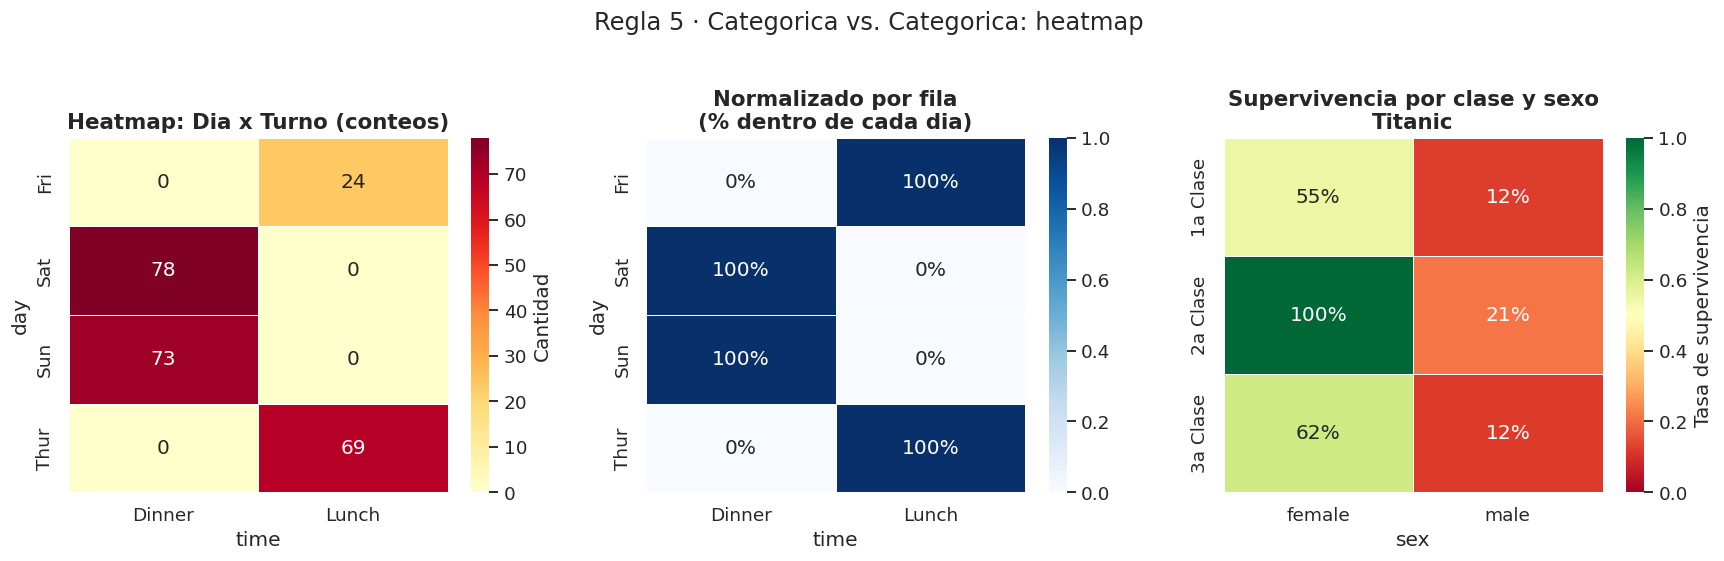

Hallazgo Titanic: mujeres de 1a clase tienen maxima supervivencia.
Hombres de 3a clase, minima. Interaccion entre dos variables categoricas.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── 5a: heatmap de conteos ────────────────────────────────────────────────────
ct = pd.crosstab(tips['day'], tips['time'])
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': 'Cantidad'})
axes[0].set_title('Heatmap: Dia x Turno (conteos)')

# ── 5b: normalizado por fila (proporciones) ───────────────────────────────────
ct_norm = ct.div(ct.sum(axis=1), axis=0).round(2)
sns.heatmap(ct_norm, annot=True, fmt='.0%', cmap='Blues', ax=axes[1],
            linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Normalizado por fila\n(% dentro de cada dia)')

# ── 5c: tasa de supervivencia Titanic: clase x sexo ──────────────────────────
ct_surv = titanic.groupby(['pclass_label','sex'])['survived'].mean().unstack()
ct_surv.index = ['1a Clase','2a Clase','3a Clase']
sns.heatmap(ct_surv, annot=True, fmt='.0%', cmap='RdYlGn', ax=axes[2],
            vmin=0, vmax=1, linewidths=0.5,
            cbar_kws={'label': 'Tasa de supervivencia'})
axes[2].set_title('Supervivencia por clase y sexo\nTitanic')

plt.suptitle('Regla 5 · Categorica vs. Categorica: heatmap', y=1.02)
plt.tight_layout()
plt.show()

print("Hallazgo Titanic: mujeres de 1a clase tienen maxima supervivencia.")
print("Hombres de 3a clase, minima. Interaccion entre dos variables categoricas.")

---
## Regla 6 · Comparar distribuciones → KDE + ECDF

**Cuándo:** Querés comparar cómo se distribuye la misma variable en diferentes grupos.

- **KDE superpuestas** → curvas de densidad, fácil de leer
- **ECDF** (Empirical CDF) → sin bins, sin parámetros, más honesta

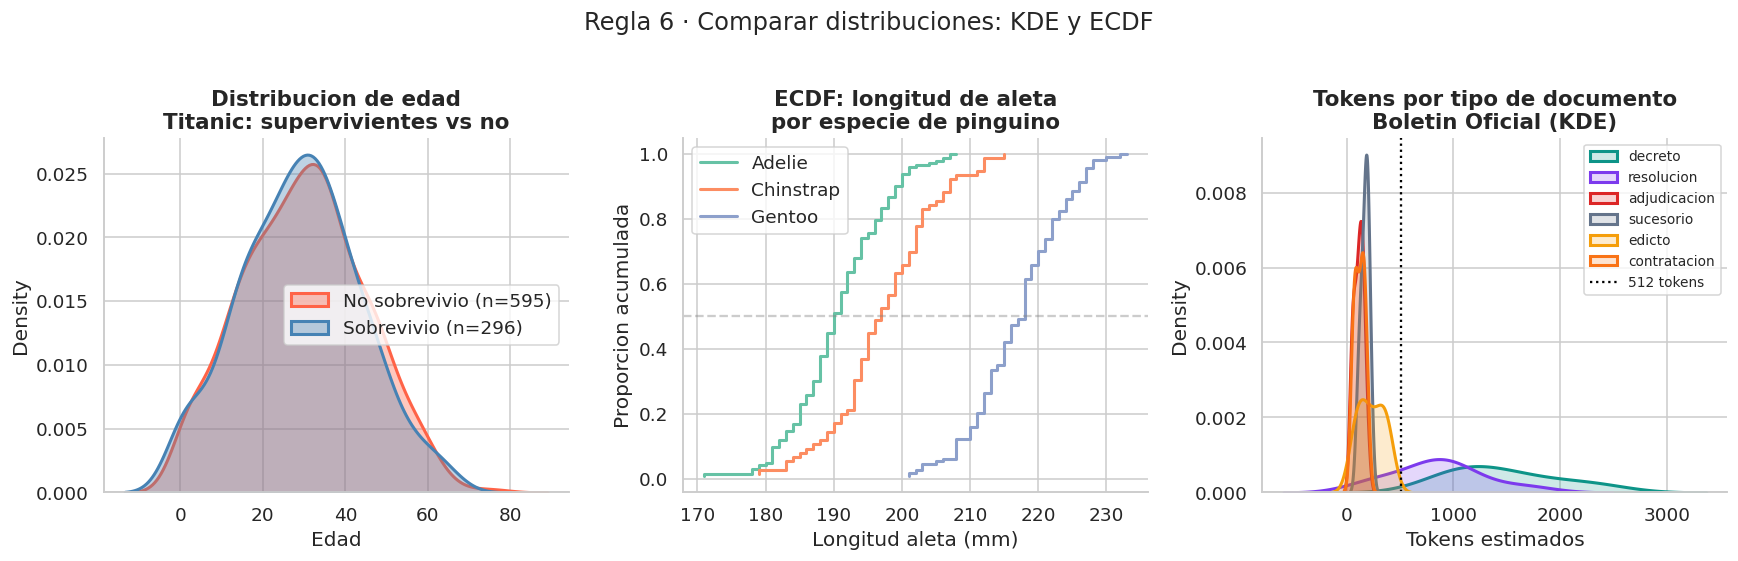

Documentos que caben en 512 tokens: 79%
-> Estrategia de chunking: la mayoria no necesita dividirse.


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── 6a: KDE superpuestas ──────────────────────────────────────────────────────
for surv, label, color in zip([0,1], ['No sobrevivio','Sobrevivio'], ['tomato','steelblue']):
    subset = titanic[titanic.survived == surv]['age']
    sns.kdeplot(subset, ax=axes[0], label=f'{label} (n={len(subset)})',
                fill=True, alpha=0.35, color=color, linewidth=2)
axes[0].set_title('Distribucion de edad\nTitanic: supervivientes vs no')
axes[0].set_xlabel('Edad')
axes[0].legend()

# ── 6b: ECDF — sin parametros, sin bins ───────────────────────────────────────
for sp, color in palette_p.items():
    subset = penguins[penguins.species == sp]['flipper_length_mm'].sort_values()
    n_vals  = len(subset)
    y_ecdf  = np.arange(1, n_vals + 1) / n_vals
    axes[1].step(subset, y_ecdf, label=sp, color=color, linewidth=2)
axes[1].set_title('ECDF: longitud de aleta\npor especie de pinguino')
axes[1].set_xlabel('Longitud aleta (mm)')
axes[1].set_ylabel('Proporcion acumulada')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.4)
axes[1].legend()

# ── 6c: KDE por tipo NLP + linea de 512 tokens ────────────────────────────────
for tipo, color in colores_nlp.items():
    subset = df_nlp[df_nlp.tipo == tipo]['tokens']
    if len(subset) > 3:
        sns.kdeplot(subset, ax=axes[2], label=tipo, color=color,
                    fill=True, alpha=0.2, linewidth=2)
axes[2].axvline(512, color='black', linestyle=':', linewidth=1.5, label='512 tokens')
axes[2].set_title('Tokens por tipo de documento\nBoletin Oficial (KDE)')
axes[2].set_xlabel('Tokens estimados')
axes[2].legend(fontsize=9)

plt.suptitle('Regla 6 · Comparar distribuciones: KDE y ECDF', y=1.02)
plt.tight_layout()
plt.show()

# Que porcentaje de documentos caben en 512 tokens?
pct_512 = (df_nlp['tokens'] <= 512).mean() * 100
print(f"Documentos que caben en 512 tokens: {pct_512:.0f}%")
print("-> Estrategia de chunking: la mayoria no necesita dividirse.")

---
## Regla 7 · Muchas variables → Heatmap de correlación + Pairplot

**Cuándo:** Tenés muchas variables numéricas y querés ver cuáles están relacionadas.

**Reglas:**
- Usar `mask` para mostrar solo el triángulo inferior
- `cmap='RdBu_r'` centrado en 0 (rojo = negativa, azul = positiva)
- `center=0` y `vmin=-1, vmax=1` para escala correcta

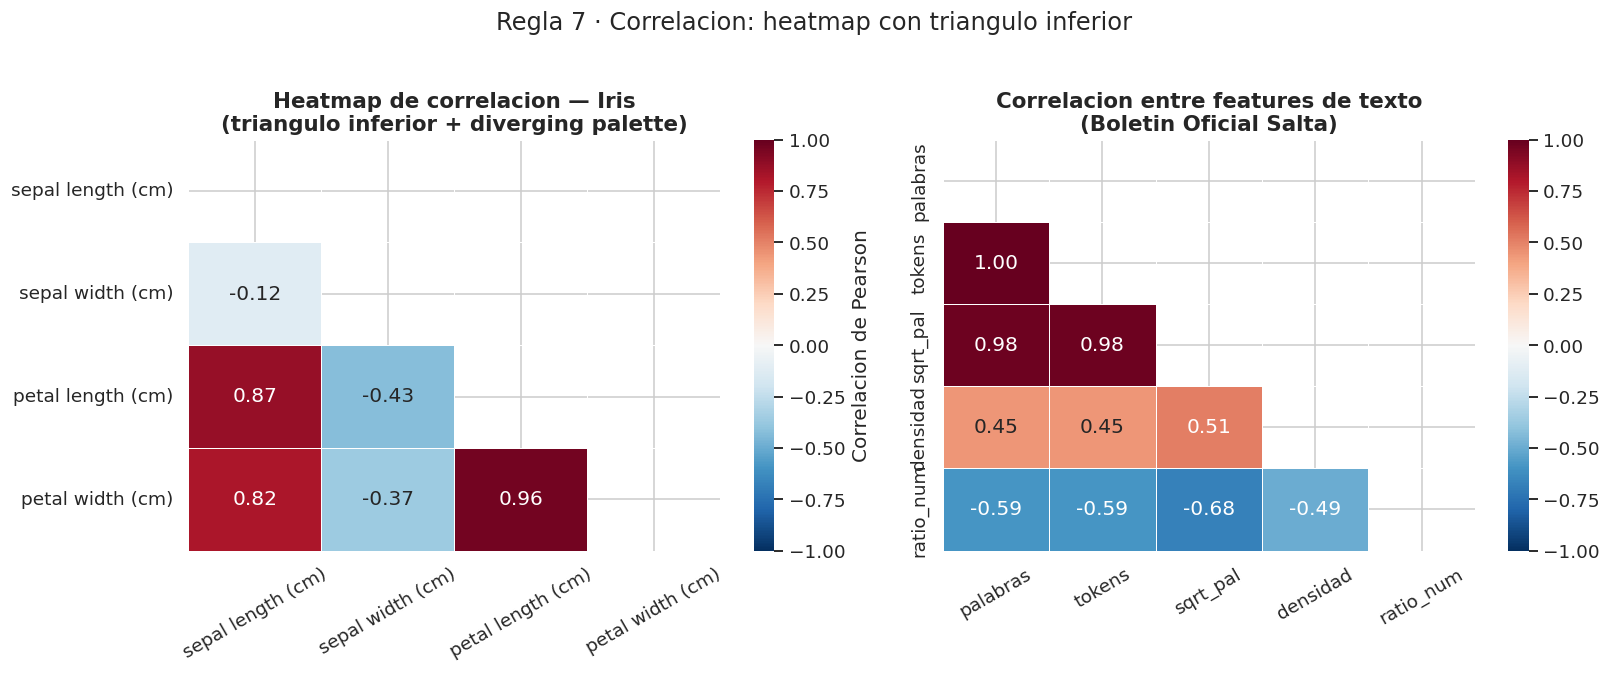

In [11]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── 7a: heatmap de correlacion — iris ────────────────────────────────────────
corr = iris[num_cols_iris].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # ocultar triangulo superior

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=axes[0], linewidths=0.5,
            cbar_kws={'label': 'Correlacion de Pearson'})
axes[0].set_title('Heatmap de correlacion — Iris\n(triangulo inferior + diverging palette)')
axes[0].tick_params(axis='x', rotation=30)

# ── 7b: correlacion NLP ───────────────────────────────────────────────────────
df_nlp['palabras_sqrt'] = np.sqrt(df_nlp['palabras'])
df_nlp['densidad']      = np.log1p(df_nlp['palabras']) * 0.3 + np.random.normal(0, 0.5, len(df_nlp))
df_nlp['ratio_num']     = np.clip(1 / (df_nlp['palabras'] * 0.05), 0, 1) + np.random.normal(0, 0.08, len(df_nlp))

corr_nlp = df_nlp[['palabras','tokens','palabras_sqrt','densidad','ratio_num']].corr()
mask_nlp  = np.triu(np.ones_like(corr_nlp, dtype=bool))

sns.heatmap(corr_nlp, mask=mask_nlp, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=axes[1], linewidths=0.5,
            xticklabels=['palabras','tokens','sqrt_pal','densidad','ratio_num'],
            yticklabels=['palabras','tokens','sqrt_pal','densidad','ratio_num'])
axes[1].set_title('Correlacion entre features de texto\n(Boletin Oficial Salta)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Regla 7 · Correlacion: heatmap con triangulo inferior', y=1.02)
plt.tight_layout()
plt.show()

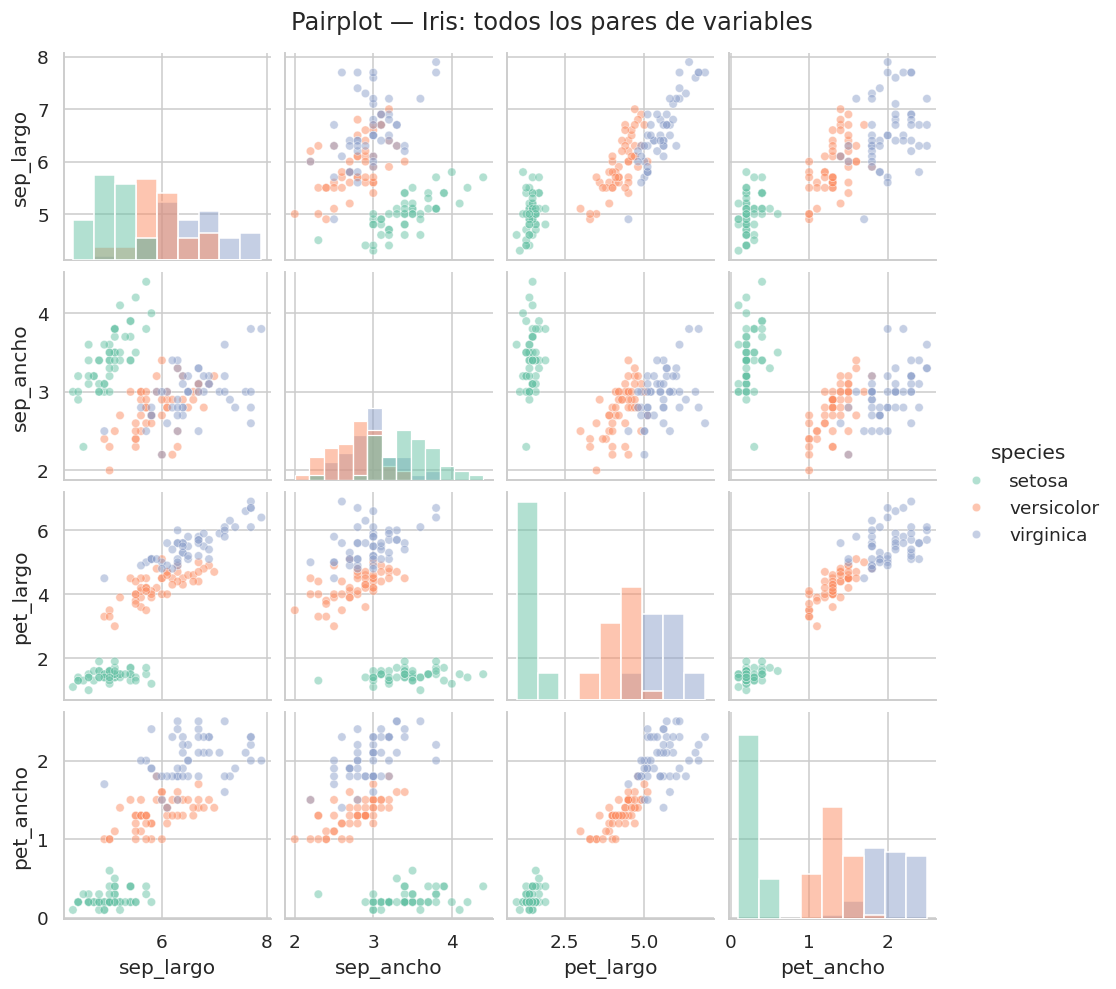

El pairplot muestra correlaciones, clusters y distribuciones en una sola vista.
Limitacion: ilegible con mas de 6-7 variables.


In [12]:
# ── 7c: pairplot — la vista mas completa ─────────────────────────────────────
iris_renamed = iris.rename(columns={
    'sepal length (cm)': 'sep_largo',
    'sepal width (cm)':  'sep_ancho',
    'petal length (cm)': 'pet_largo',
    'petal width (cm)':  'pet_ancho',
})

g = sns.pairplot(
    iris_renamed,
    vars=['sep_largo','sep_ancho','pet_largo','pet_ancho'],
    hue='species',
    palette={'setosa': COLOR_A, 'versicolor': COLOR_B, 'virginica': COLOR_C},
    diag_kind='hist',
    plot_kws={'alpha': 0.5, 's': 30},
    height=2.2
)
g.figure.suptitle('Pairplot — Iris: todos los pares de variables', y=1.02)
plt.show()

print("El pairplot muestra correlaciones, clusters y distribuciones en una sola vista.")
print("Limitacion: ilegible con mas de 6-7 variables.")

---
## Regla 8 · Datos de texto / NLP → Frecuencias de términos

**Cuándo:** Tenés texto y querés entender el vocabulario o los términos dominantes por clase.

**Herramientas:**
- **Barras de frecuencia** → top N términos por clase (principal)
- **WordCloud** → visual y comunicativo pero menos preciso (secundario)

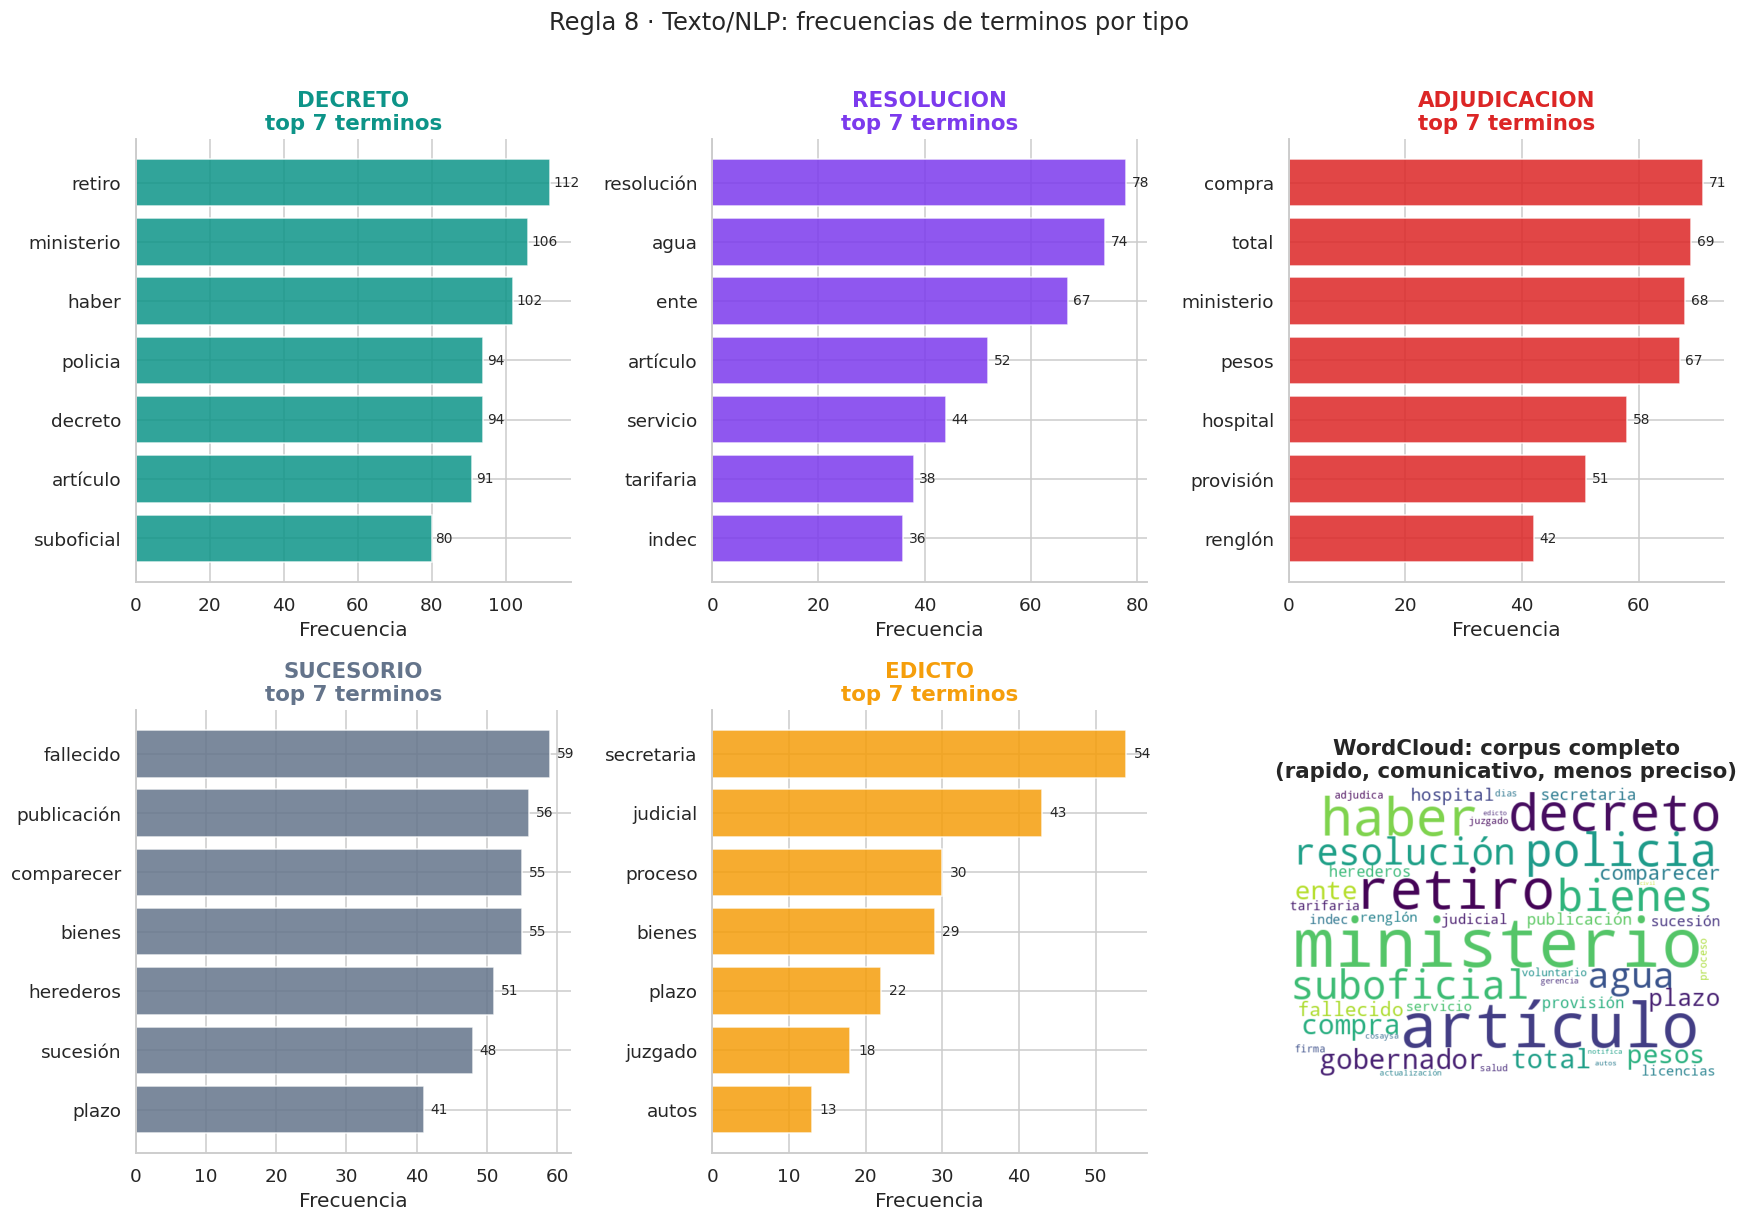

Los vocabularios son distintos por tipo -> alta separabilidad.
-> TF-IDF + Logistic Regression puede ser suficiente para Track B.


In [13]:
# Frecuencias simuladas del Boletin Oficial por tipo
np.random.seed(42)
vocab_por_tipo = {
    'decreto':      dict(zip(['gobernador','retiro','voluntario','artículo','suboficial',
                               'licencias','haber','ministerio','decreto','policia'],
                              np.random.randint(20, 120, 10))),
    'resolucion':   dict(zip(['tarifaria','cosaysa','indec','ente','actualización',
                               'servicio','artículo','gerencia','resolución','agua'],
                              np.random.randint(15, 100, 10))),
    'adjudicacion': dict(zip(['adjudica','renglón','pesos','firma','hospital',
                               'ministerio','provisión','total','salud','compra'],
                              np.random.randint(10, 80, 10))),
    'sucesorio':    dict(zip(['herederos','bienes','sucesión','fallecido','publicación',
                               'juzgado','plazo','comparecer','edicto','dias'],
                              np.random.randint(5, 60, 10))),
    'edicto':       dict(zip(['notifica','judicial','plazo','comparecer','bienes',
                               'juzgado','secretaria','autos','proceso','civil'],
                              np.random.randint(5, 55, 10))),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 11))
axes_flat = [axes[0,0], axes[0,1], axes[0,2], axes[1,0], axes[1,1]]

for ax, (tipo, freq_dict) in zip(axes_flat, vocab_por_tipo.items()):
    freq_sorted = dict(sorted(freq_dict.items(), key=lambda x: x[1]))
    terminos = list(freq_sorted.keys())[-7:]
    valores  = [freq_sorted[t] for t in terminos]
    color    = colores_nlp.get(tipo, 'gray')
    bars     = ax.barh(terminos, valores, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'{tipo.upper()}\ntop 7 terminos', color=color, fontweight='bold')
    ax.set_xlabel('Frecuencia')
    for bar, val in zip(bars, valores):
        ax.text(val + 1, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=9)

# WordCloud en el ultimo panel
try:
    from wordcloud import WordCloud
    todos = {}
    for freq_dict in vocab_por_tipo.values():
        for term, cnt in freq_dict.items():
            todos[term] = todos.get(term, 0) + cnt
    wc = WordCloud(width=600, height=400, background_color='white',
                   max_words=60, colormap='viridis').generate_from_frequencies(todos)
    axes[1,2].imshow(wc, interpolation='bilinear')
    axes[1,2].axis('off')
    axes[1,2].set_title('WordCloud: corpus completo\n(rapido, comunicativo, menos preciso)')
except ImportError:
    axes[1,2].text(0.5, 0.5, 'pip install wordcloud',
                   ha='center', va='center', transform=axes[1,2].transAxes)
    axes[1,2].axis('off')

plt.suptitle('Regla 8 · Texto/NLP: frecuencias de terminos por tipo', y=1.01)
plt.tight_layout()
plt.show()

print("Los vocabularios son distintos por tipo -> alta separabilidad.")
print("-> TF-IDF + Logistic Regression puede ser suficiente para Track B.")

---
## Panel EDA completo (2×3)

Cuando presentás el EDA de un corpus NLP, esta estructura de 2×3 funciona bien.

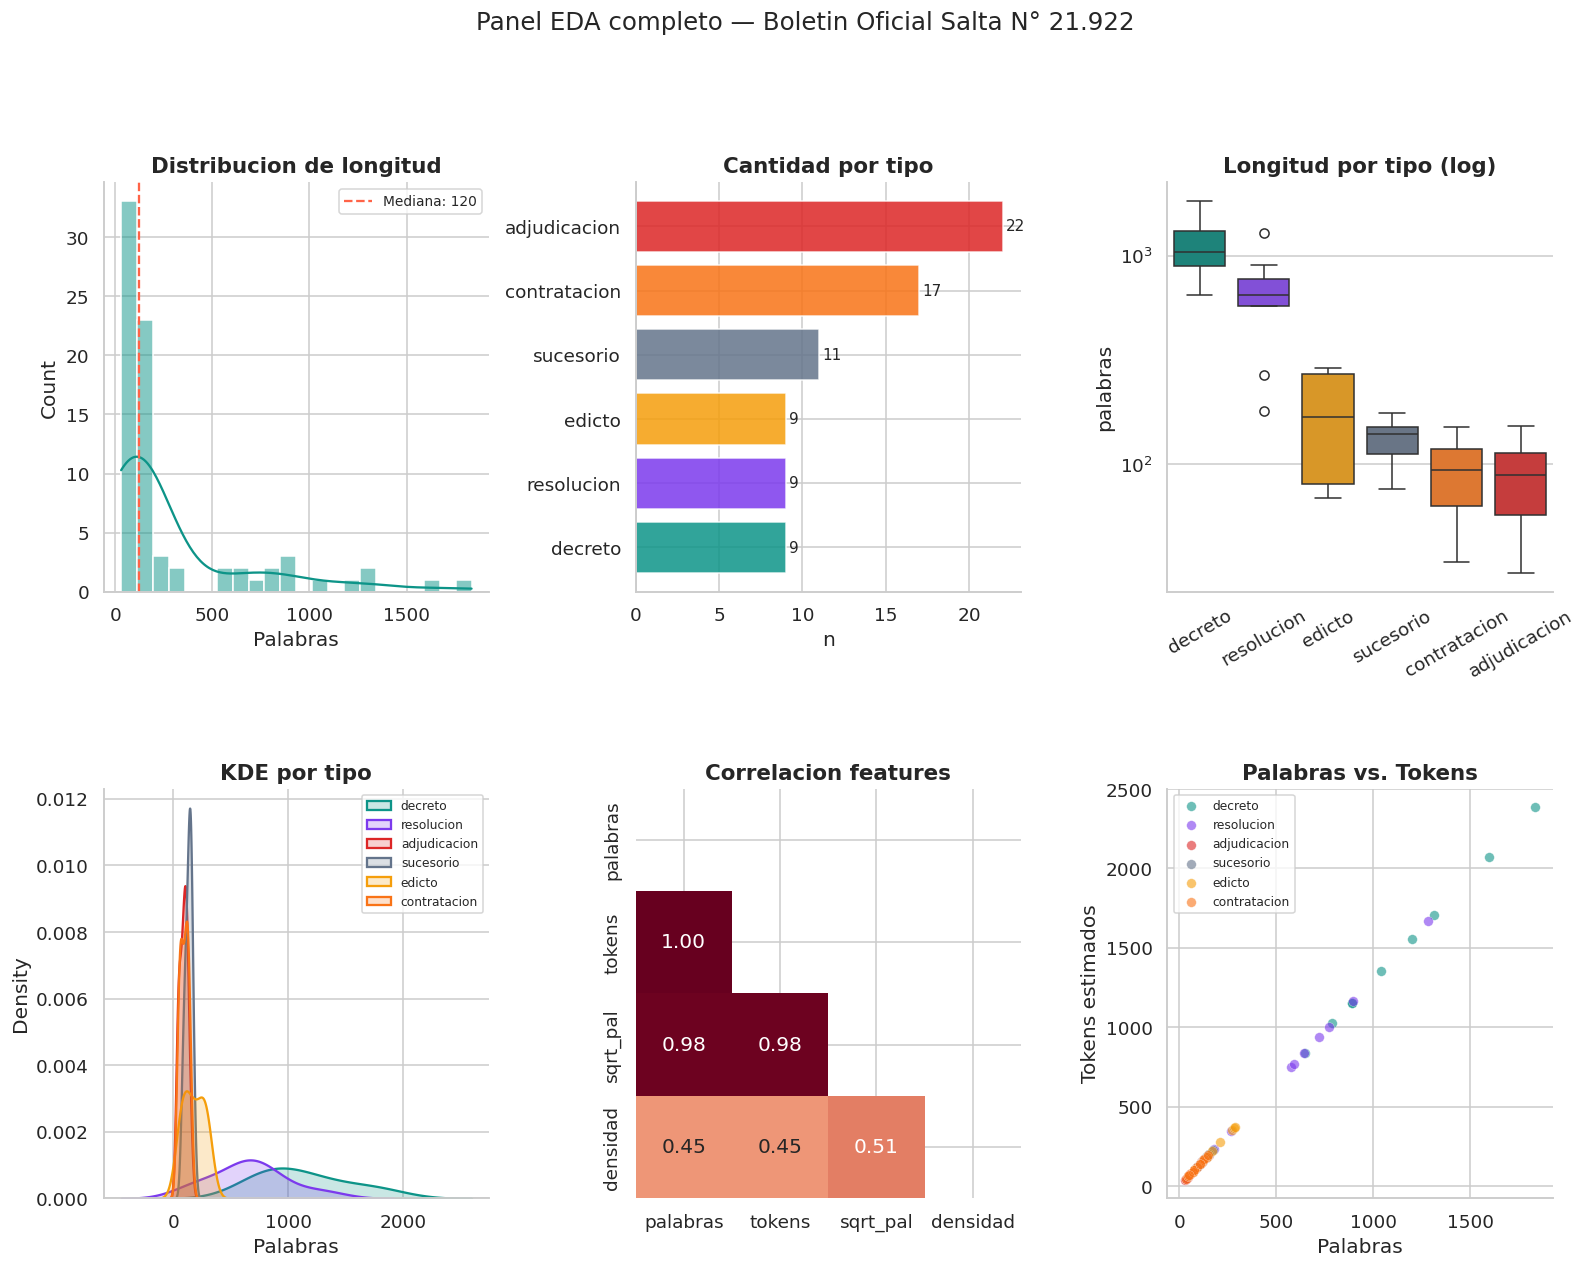

In [14]:
fig = plt.figure(figsize=(17, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.38)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])

# 1. Distribucion global de longitud
sns.histplot(df_nlp['palabras'], bins=22, kde=True, color='#0D9488', ax=ax1, edgecolor='white')
ax1.axvline(df_nlp['palabras'].median(), color='tomato', linestyle='--',
            label=f'Mediana: {df_nlp["palabras"].median():.0f}')
ax1.set_title('Distribucion de longitud')
ax1.set_xlabel('Palabras')
ax1.legend(fontsize=9)

# 2. Cantidad por tipo
cnt = df_nlp['tipo'].value_counts().sort_values()
c2  = [colores_nlp.get(t,'gray') for t in cnt.index]
ax2.barh(cnt.index, cnt.values, color=c2, edgecolor='white', alpha=0.85)
ax2.set_title('Cantidad por tipo')
ax2.set_xlabel('n')
for bar, v in zip(ax2.patches, cnt.values):
    ax2.text(v+0.2, bar.get_y()+bar.get_height()/2, str(v), va='center', fontsize=10)

# 3. Boxplot longitud × tipo
orden3 = df_nlp.groupby('tipo')['palabras'].median().sort_values(ascending=False).index
sns.boxplot(data=df_nlp, x='tipo', y='palabras', order=orden3,
            palette=colores_nlp, ax=ax3)
ax3.set_yscale('log')
ax3.set_title('Longitud por tipo (log)')
ax3.set_xlabel('')
ax3.tick_params(axis='x', rotation=30)

# 4. KDE por tipo
for tipo, color in colores_nlp.items():
    sub = df_nlp[df_nlp.tipo==tipo]['palabras']
    if len(sub) > 3:
        sns.kdeplot(sub, ax=ax4, label=tipo, color=color, fill=True, alpha=0.22, linewidth=1.5)
ax4.set_title('KDE por tipo')
ax4.set_xlabel('Palabras')
ax4.legend(fontsize=8)

# 5. Heatmap correlacion
corr5 = df_nlp[['palabras','tokens','palabras_sqrt','densidad']].corr()
mask5 = np.triu(np.ones_like(corr5, dtype=bool))
sns.heatmap(corr5, mask=mask5, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax5, cbar=False,
            xticklabels=['palabras','tokens','sqrt_pal','densidad'],
            yticklabels=['palabras','tokens','sqrt_pal','densidad'])
ax5.set_title('Correlacion features')

# 6. Scatter palabras vs tokens
for tipo, color in colores_nlp.items():
    sub = df_nlp[df_nlp.tipo==tipo]
    ax6.scatter(sub['palabras'], sub['tokens'], color=color, label=tipo,
                alpha=0.6, s=40, edgecolors='white', linewidth=0.3)
ax6.set_title('Palabras vs. Tokens')
ax6.set_xlabel('Palabras')
ax6.set_ylabel('Tokens estimados')
ax6.legend(fontsize=8)

fig.suptitle('Panel EDA completo — Boletin Oficial Salta N° 21.922', fontsize=16, y=1.01)
plt.show()

---
## Tabla de decisión — referencia rápida

In [15]:
tabla = [
    ("1 Numérica",              "Histograma + KDE",          "sns.histplot(kde=True)",              "Nunca omitas el kde"),
    ("1 Categórica",            "Barras horizontales",       "sns.countplot() / ax.barh()",         "Evitar pie chart si > 3 categorías"),
    ("Numérica × Numérica",     "Scatter plot",              "sns.scatterplot() / sns.regplot()",   "Si N > 5000: hexbin (overplotting)"),
    ("Numérica × Categórica",   "Boxplot + Stripplot",       "sns.boxplot() + sns.stripplot()",     "Evitar barplot de medias"),
    ("Categórica × Categórica", "Heatmap de conteos",        "pd.crosstab() + sns.heatmap()",       "Mostrar conteo Y proporciones"),
    ("Distribuciones múltiples","KDE superpuestas / ECDF",   "sns.kdeplot(hue=...)",                "Histogramas apilados dificultan comparación"),
    ("Muchas variables numér.", "Heatmap correlación",       "df.corr() + sns.heatmap(mask=...)",   "Mostrar siempre triangulo inferior"),
    ("Vista exploratoria",      "Pairplot",                  "sns.pairplot(hue=...)",               "Ilegible con > 6-7 variables"),
    ("Texto / NLP",             "Barras de frecuencia",      "Counter() + ax.barh()",               "WordCloud es decorativo, no analítico"),
]

print(f"{'Situacion':<28} {'Grafico':<25} {'Codigo seaborn':<36} {'Evitar'}")
print("-" * 120)
for row in tabla:
    print(f"{row[0]:<28} {row[1]:<25} {row[2]:<36} {row[3]}")

Situacion                    Grafico                   Codigo seaborn                       Evitar
------------------------------------------------------------------------------------------------------------------------
1 Numérica                   Histograma + KDE          sns.histplot(kde=True)               Nunca omitas el kde
1 Categórica                 Barras horizontales       sns.countplot() / ax.barh()          Evitar pie chart si > 3 categorías
Numérica × Numérica          Scatter plot              sns.scatterplot() / sns.regplot()    Si N > 5000: hexbin (overplotting)
Numérica × Categórica        Boxplot + Stripplot       sns.boxplot() + sns.stripplot()      Evitar barplot de medias
Categórica × Categórica      Heatmap de conteos        pd.crosstab() + sns.heatmap()        Mostrar conteo Y proporciones
Distribuciones múltiples     KDE superpuestas / ECDF   sns.kdeplot(hue=...)                 Histogramas apilados dificultan comparación
Muchas variables numér.      Heatmap co

---
## Aplicá estas reglas a tu dataset

Para cada gráfico completá este template:

In [16]:
# ─── ANÁLISIS 1 ──────────────────────────────────────────────────────────────
# Variables:            [nombre y tipo: numérica / categórica / texto]
# Pregunta:             [¿qué querés saber?]
# Gráfico elegido:      [histplot / boxplot / scatter / heatmap / etc.]
# Justificación:        [¿por qué este gráfico? → consultá la tabla de decisión]

# fig, ax = plt.subplots(figsize=(10, 5))
# sns.GRÁFICO(data=tu_df, x='...', y='...', palette='Set2', ...)
# ax.set_title('Título que describe el HALLAZGO, no el nombre de la variable')
# plt.show()

# Hallazgo:             [1 oración con lo que encontraste]
# Impacto en el modelo: [¿cómo afecta a tu RAG o clasificador?]

print("Completá este template con tu dataset.")
print("Minimo: 3 visualizaciones de tipos distintos según la tabla de decisión.")

Completá este template con tu dataset.
Minimo: 3 visualizaciones de tipos distintos según la tabla de decisión.


---
## Checklist antes de entregar

- [ ] ¿El gráfico elegido es el correcto para el tipo de dato?
- [ ] ¿El título describe el **hallazgo** y no solo el nombre de la variable?
- [ ] ¿Los ejes tienen labels con unidades cuando corresponde?
- [ ] ¿Hay un markdown debajo con el hallazgo documentado?
- [ ] ¿Usaste alpha para evitar overplotting en scatter plots?
- [ ] ¿El heatmap tiene máscara de triángulo y cmap diverging?
- [ ] ¿Evitaste el barplot de medias y el pie chart con muchas categorías?

---
*Diplomatura en IA UBA 2026 · Clase 2 · Visualización para EDA*

Muestra de datos (Numérica):
   total_bill
0       11.21
1       35.54
2       14.79
3        9.05
4       21.90


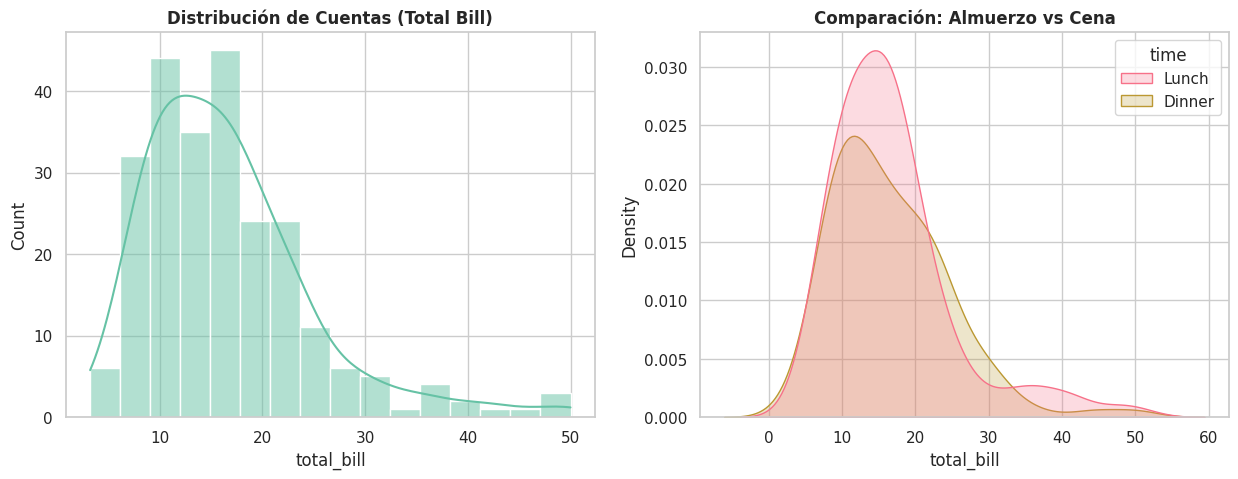


Conteo de categorías (Días):
day
Sat     68
Thur    61
Fri     60
Sun     55
Name: count, dtype: int64


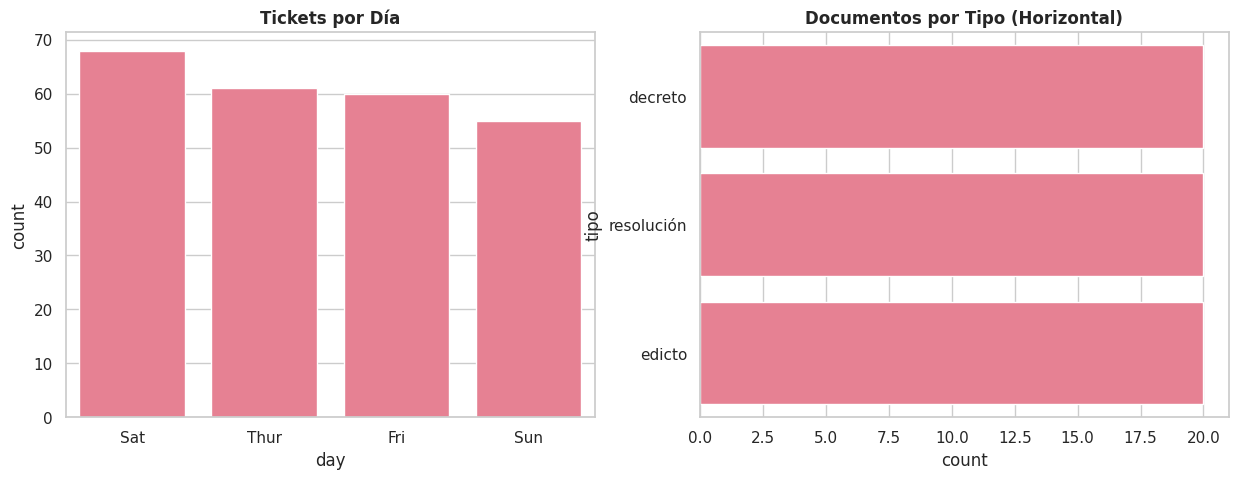


Relación entre variables:
   total_bill   tip
0       11.21  2.02
1       35.54  3.46
2       14.79  3.20
3        9.05  2.40
4       21.90  3.07


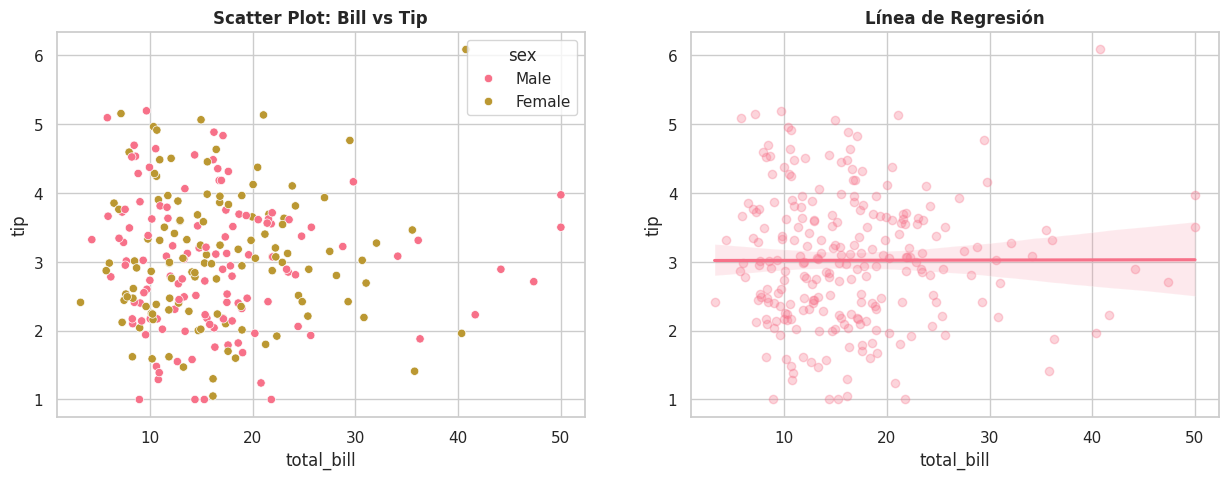


Distribución por grupos (Edad por Clase):
pclass
1    30.943240
2    29.612682
3    31.344623
Name: age, dtype: float64


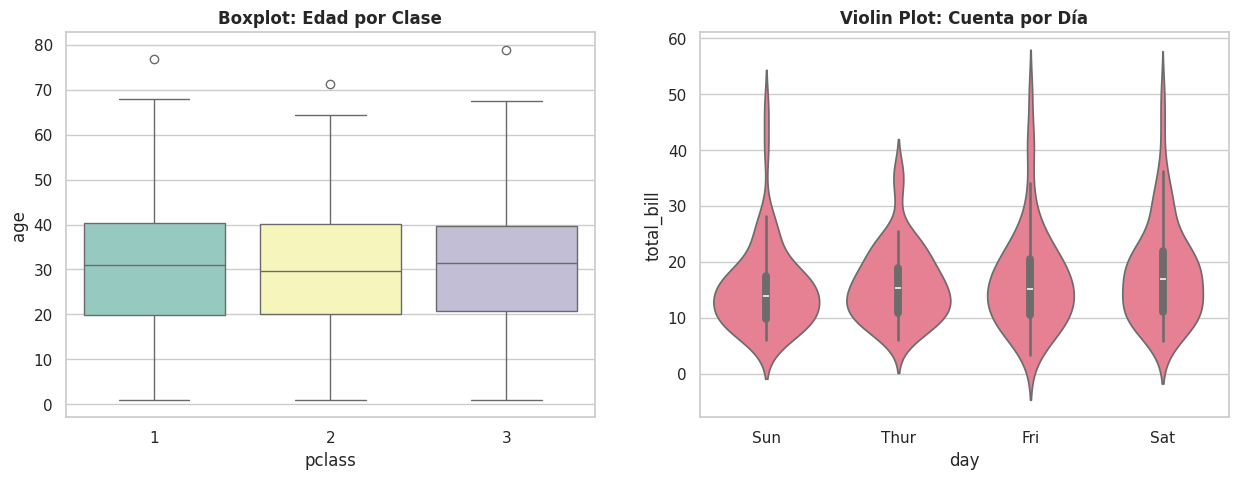


Tabla de contingencia:
sex   Female  Male
day               
Fri       28    32
Sat       32    36
Sun       29    26
Thur      31    30


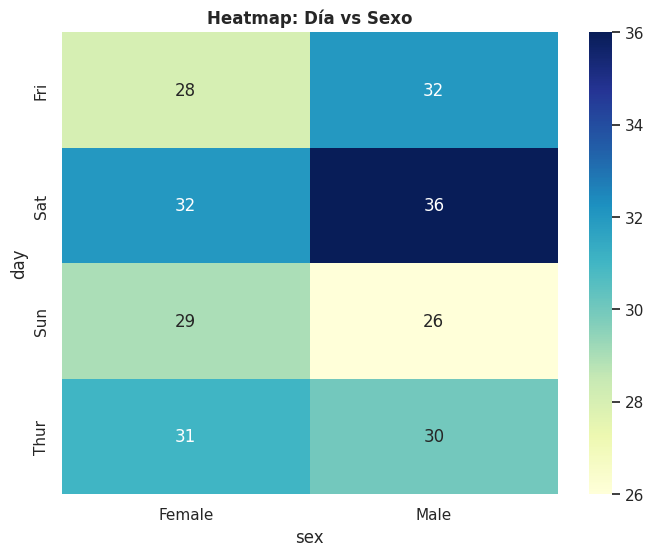


Matriz de correlación:
            total_bill       tip      size
total_bill    1.000000  0.001994 -0.094889
tip           0.001994  1.000000 -0.048773
size         -0.094889 -0.048773  1.000000


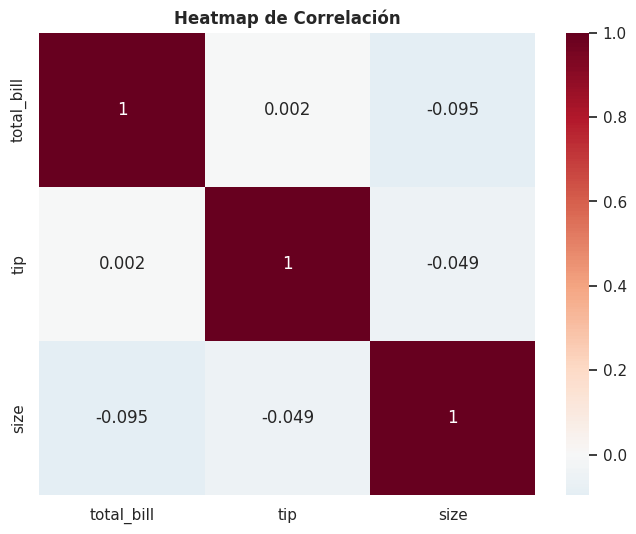


Datos de texto:
      tipo  palabras  tokens
0  decreto       849    1018
1  decreto       513     615
2  decreto       599     718
3  decreto       192     230
4  decreto       784     940


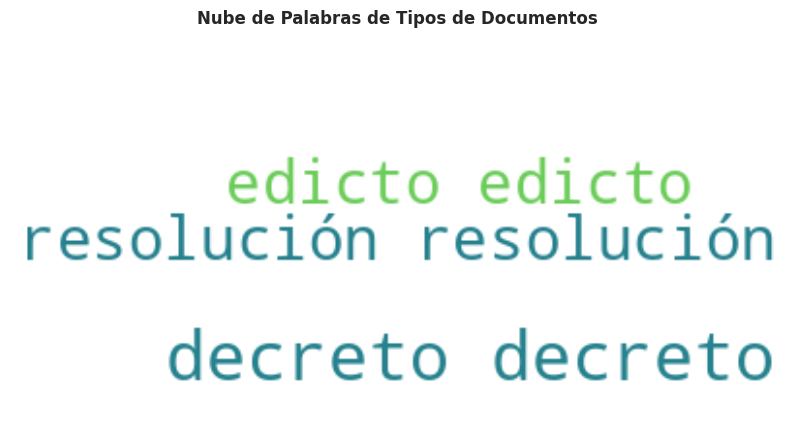

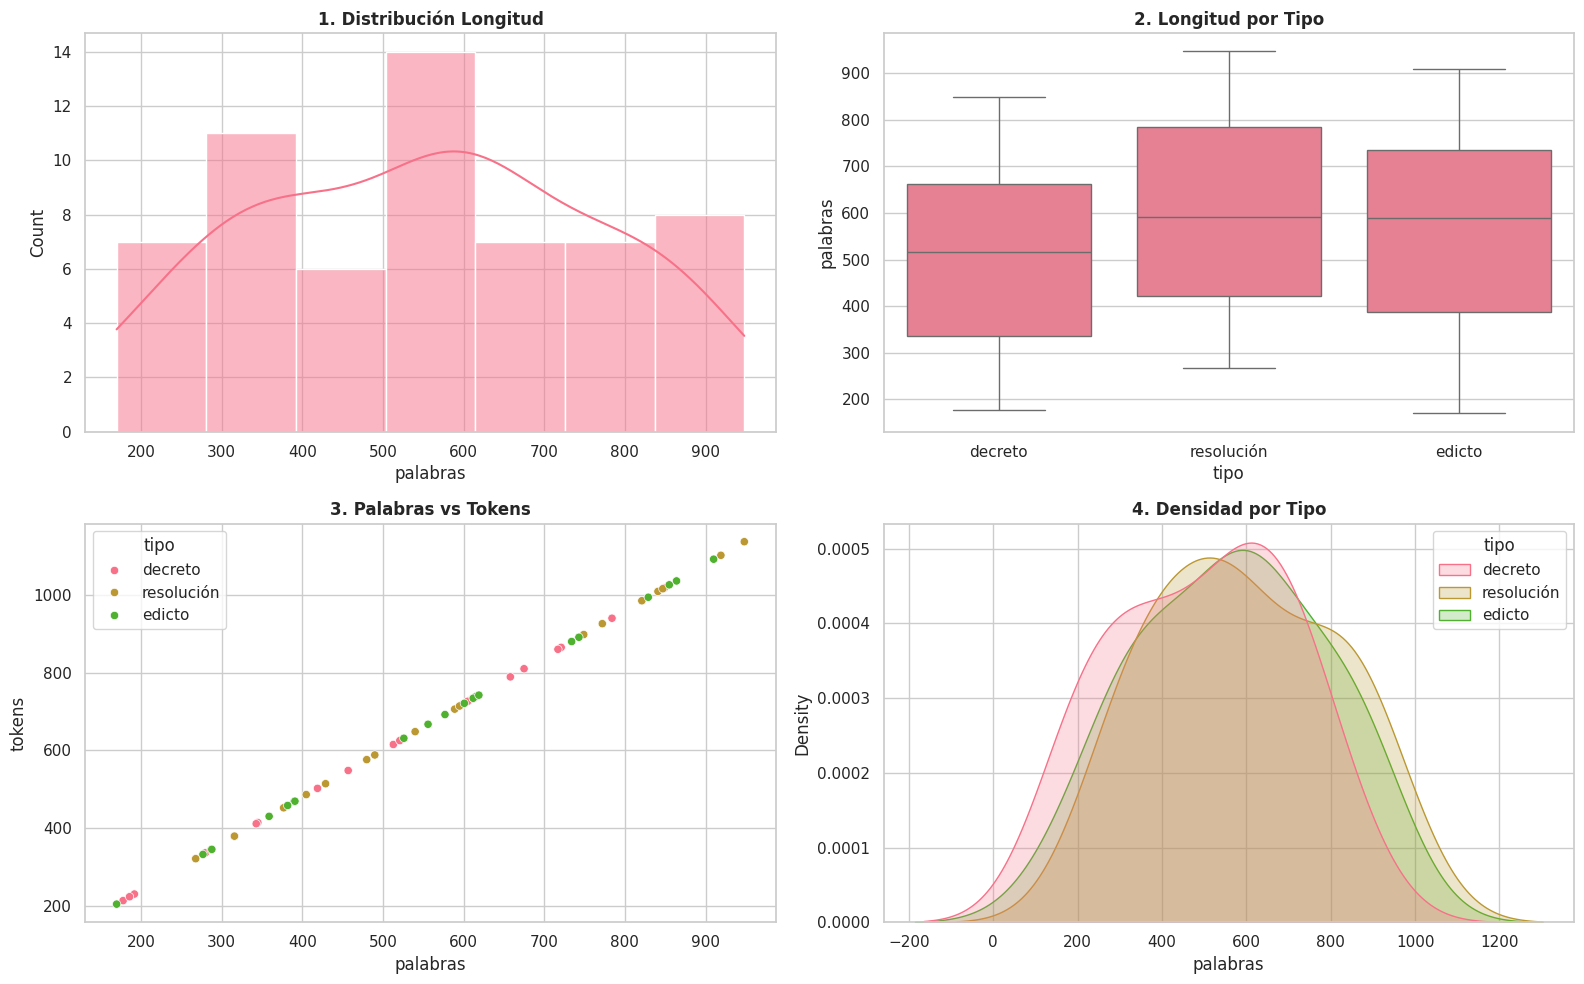

In [17]:
# 1. SETUP Y LIBRERÍAS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Estilo global simple
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams.update({'figure.figsize': (12, 6), 'figure.dpi': 100})
COLOR_A, COLOR_B, COLOR_C, COLOR_D = sns.color_palette("Set2", 4)

# 2. GENERACIÓN DE DATASETS (Basado en Clase2_Visualizacion_EDA.ipynb)[cite: 1]
# Tips
n = 244
tips = pd.DataFrame({
    'total_bill': np.clip(np.random.lognormal(2.7, 0.47, n), 3, 50).round(2),
    'tip': np.clip(np.random.normal(3, 1, n), 1, 10).round(2),
    'sex': np.random.choice(['Male','Female'], n),
    'day': np.random.choice(['Thur','Fri','Sat','Sun'], n),
    'time': np.random.choice(['Lunch','Dinner'], n),
    'size': np.random.choice([2,3,4], n)
})

# Titanic
n_t = 891
titanic = pd.DataFrame({
    'survived': np.random.choice([0, 1], n_t, p=[0.62, 0.38]),
    'pclass': np.random.choice([1, 2, 3], n_t),
    'sex': np.random.choice(['male', 'female'], n_t),
    'age': np.random.normal(30, 15, n_t).clip(1, 80)
})

# NLP (Boletín Oficial sintético)
nlp_rows = []
for tipo in ['decreto', 'resolución', 'edicto']:
    for _ in range(20):
        pal = np.random.randint(100, 1000)
        nlp_rows.append({'tipo': tipo, 'palabras': pal, 'tokens': int(pal * 1.2)})
df_nlp = pd.DataFrame(nlp_rows)

# --- REGLA 1: UNA VARIABLE NUMÉRICA ---
print("Muestra de datos (Numérica):")
print(tips[['total_bill']].head())

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=tips, x='total_bill', kde=True, color=COLOR_A)
plt.title('Distribución de Cuentas (Total Bill)')

plt.subplot(1, 2, 2)
sns.kdeplot(data=tips, x='total_bill', hue='time', fill=True)
plt.title('Comparación: Almuerzo vs Cena')
plt.show()

# --- REGLA 2: UNA VARIABLE CATEGÓRICA ---
print("\nConteo de categorías (Días):")
print(tips['day'].value_counts())

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=tips, x='day', order=tips['day'].value_counts().index)
plt.title('Tickets por Día')

plt.subplot(1, 2, 2)
sns.countplot(data=df_nlp, y='tipo')
plt.title('Documentos por Tipo (Horizontal)')
plt.show()

# --- REGLA 3: NUMÉRICA VS NUMÉRICA ---
print("\nRelación entre variables:")
print(tips[['total_bill', 'tip']].head())

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='sex')
plt.title('Scatter Plot: Bill vs Tip')

plt.subplot(1, 2, 2)
sns.regplot(data=tips, x='total_bill', y='tip', scatter_kws={'alpha':0.3})
plt.title('Línea de Regresión')
plt.show()

# --- REGLA 4: NUMÉRICA VS CATEGÓRICA (BOXPLOTS) ---
print("\nDistribución por grupos (Edad por Clase):")
print(titanic.groupby('pclass')['age'].median())

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=titanic, x='pclass', y='age', palette='Set3')
plt.title('Boxplot: Edad por Clase')

plt.subplot(1, 2, 2)
sns.violinplot(data=tips, x='day', y='total_bill')
plt.title('Violin Plot: Cuenta por Día')
plt.show()

# --- REGLA 5: CATEGÓRICA VS CATEGÓRICA (HEATMAPS) ---
print("\nTabla de contingencia:")
ct = pd.crosstab(tips['day'], tips['sex'])
print(ct)

plt.figure(figsize=(8, 6))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap: Día vs Sexo')
plt.show()

# --- REGLA 7: CORRELACIÓN ---
print("\nMatriz de correlación:")
corr = tips.select_dtypes('number').corr()
print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0)
plt.title('Heatmap de Correlación')
plt.show()

# --- REGLA 8: TEXTO / WORDCLOUD ---
print("\nDatos de texto:")
print(df_nlp.head())

plt.figure(figsize=(10, 6))
text = " ".join(df_nlp['tipo'])
wc = WordCloud(background_color='white').generate(text)
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras de Tipos de Documentos')
plt.show()

# --- BONUS: PANEL EDA COMPLETO (Sin POO avanzada) ---
plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
sns.histplot(df_nlp['palabras'], kde=True)
plt.title('1. Distribución Longitud')

plt.subplot(2, 2, 2)
sns.boxplot(data=df_nlp, x='tipo', y='palabras')
plt.title('2. Longitud por Tipo')

plt.subplot(2, 2, 3)
sns.scatterplot(data=df_nlp, x='palabras', y='tokens', hue='tipo')
plt.title('3. Palabras vs Tokens')

plt.subplot(2, 2, 4)
sns.kdeplot(data=df_nlp, x='palabras', hue='tipo', fill=True)
plt.title('4. Densidad por Tipo')

plt.tight_layout()
plt.show()